In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from scipy.stats import mstats
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_theme()

In [15]:
file_name = 'synthetic_fraud_dataset.csv'
df = pd.read_csv(file_name)

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [16]:
# Tabla de valores faltantes (NA)
na_counts = df.isna().sum()
na_pct = df.isna().mean() * 100

na_table = (
    pd.DataFrame({
        "NA_Count": na_counts,
        "NA_Percentage": na_pct
    })
    .sort_values("NA_Count", ascending=False)
)

na_table


,NA_Count,NA_Percentage
Transaction_ID,0,0.0
Daily_Transaction_Count,0,0.0
Is_Weekend,0,0.0
Risk_Score,0,0.0
Authentication_Method,0,0.0
Transaction_Distance,0,0.0
Card_Age,0,0.0
Card_Type,0,0.0
Failed_Transaction_Count_7d,0,0.0
Avg_Transaction_Amount_7d,0,0.0


In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols


['Transaction_Amount',
 'Account_Balance',
 'IP_Address_Flag',
 'Previous_Fraudulent_Activity',
 'Daily_Transaction_Count',
 'Avg_Transaction_Amount_7d',
 'Failed_Transaction_Count_7d',
 'Card_Age',
 'Transaction_Distance',
 'Risk_Score',
 'Is_Weekend',
 'Fraud_Label']

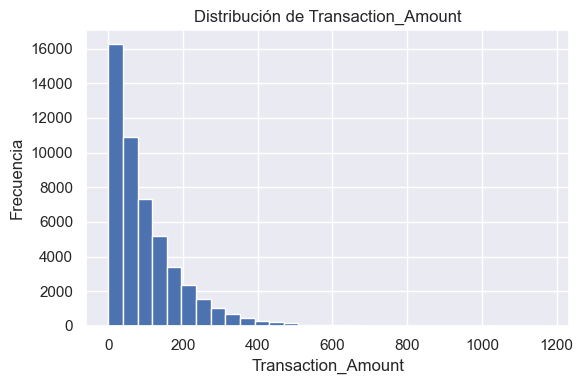

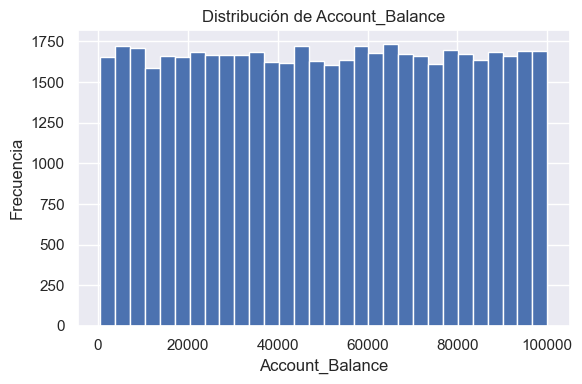

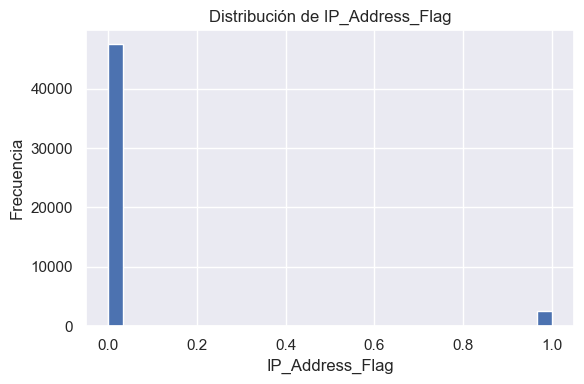

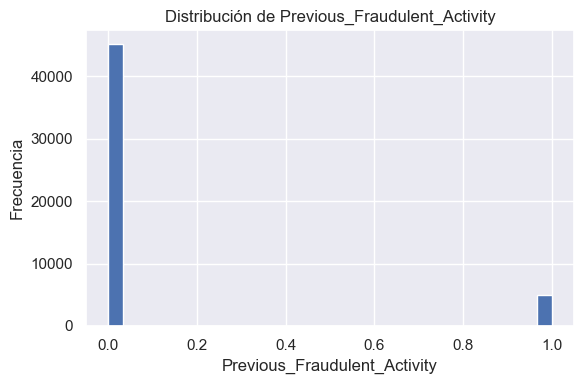

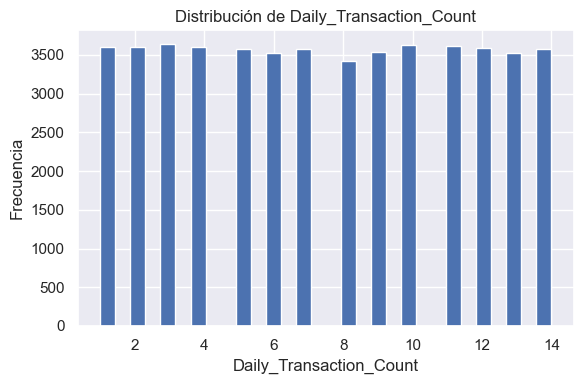

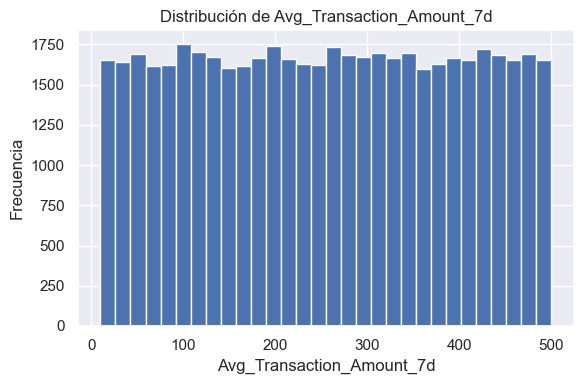

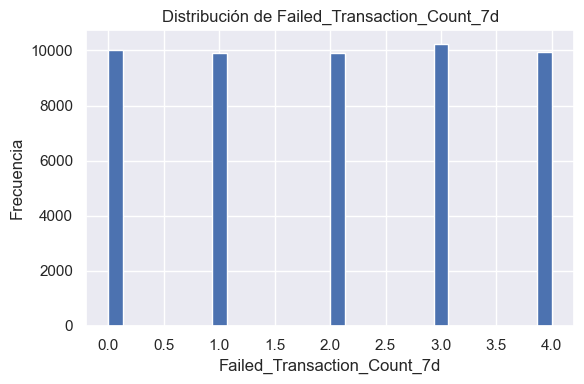

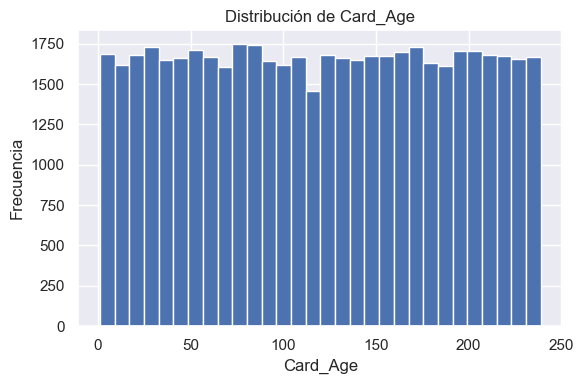

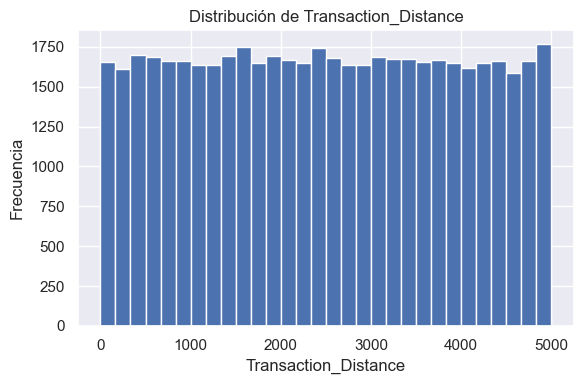

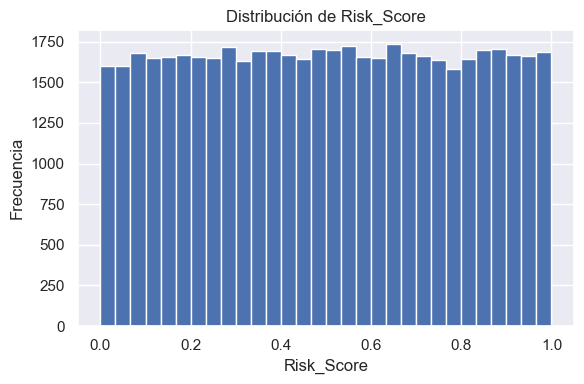

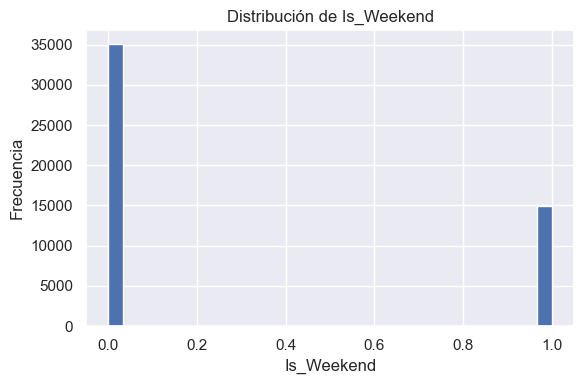

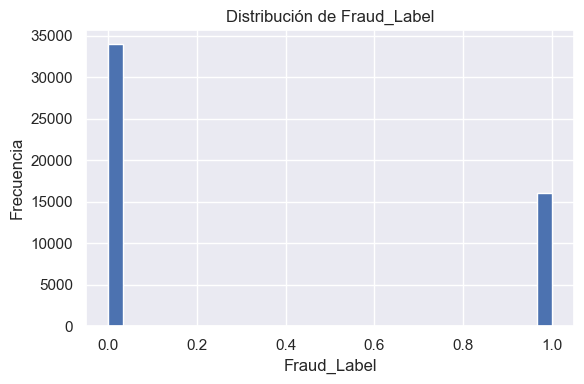

In [18]:
# Histogramas para todas las variables numéricas
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


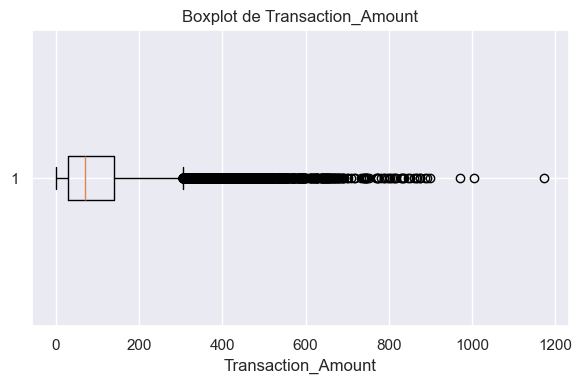

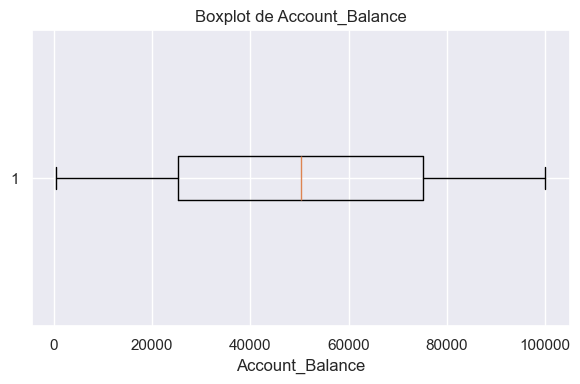

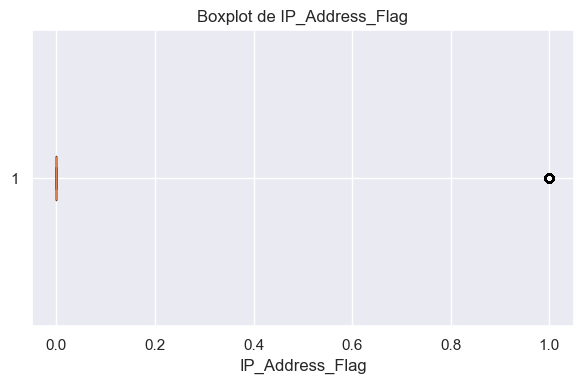

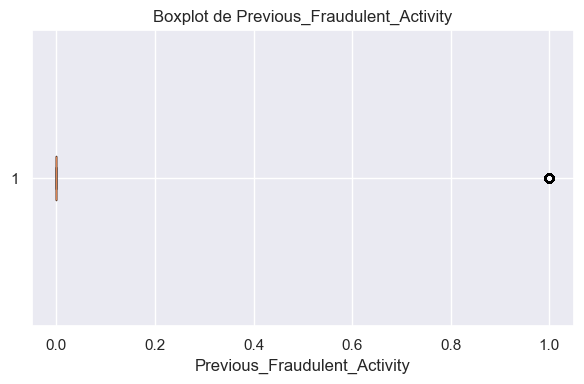

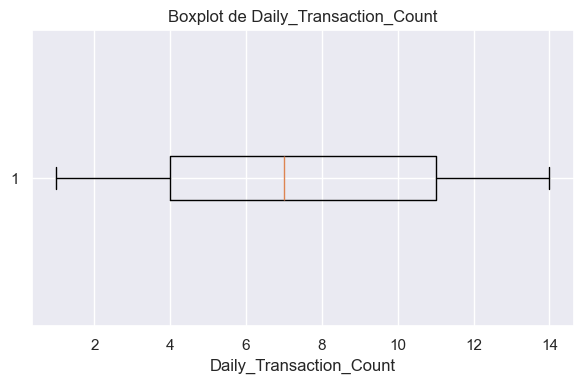

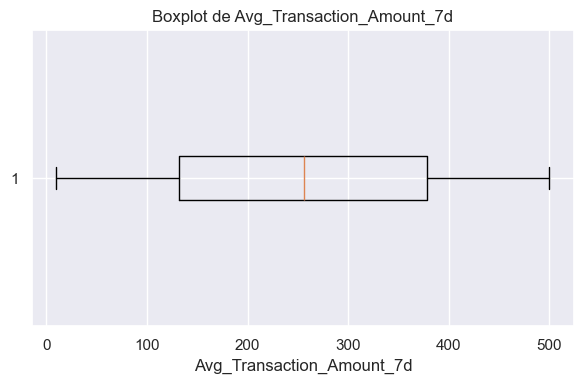

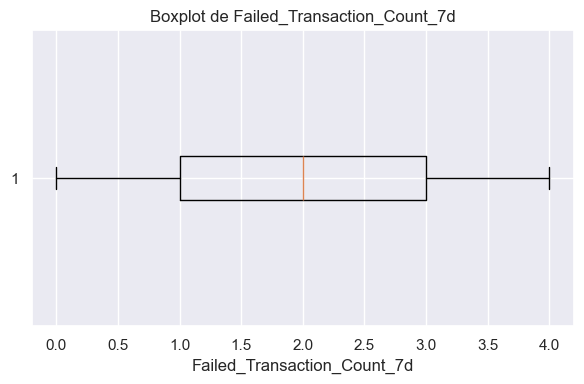

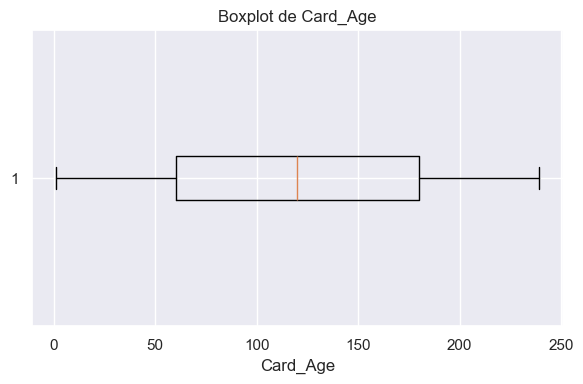

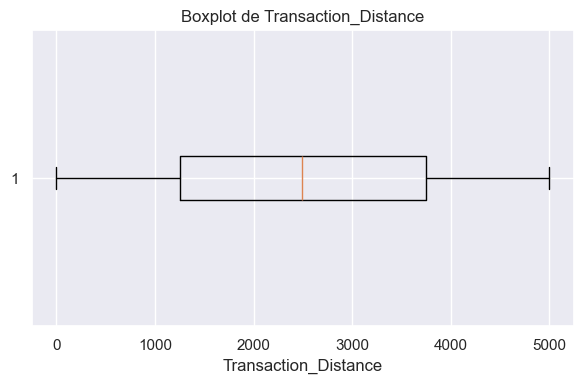

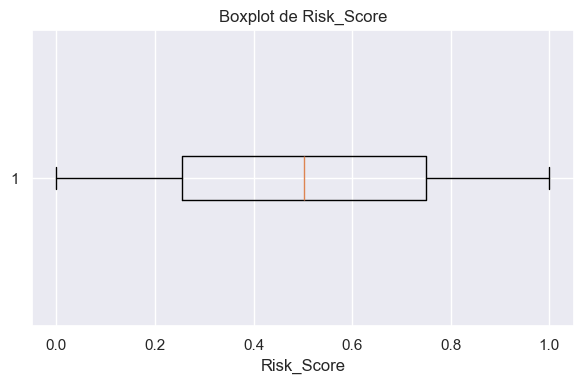

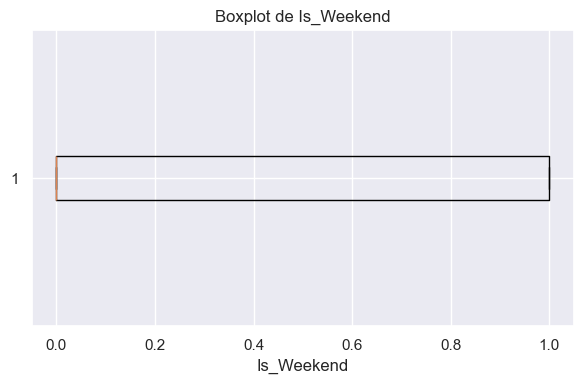

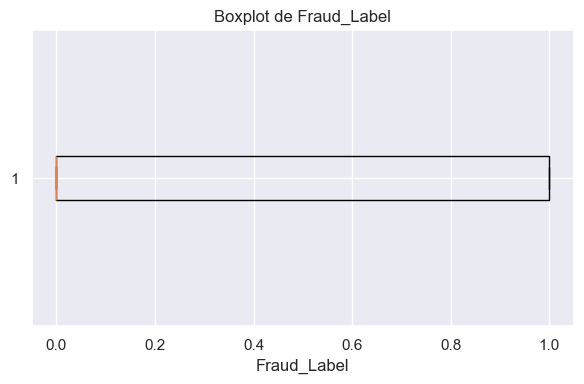

In [19]:
# Boxplots para todas las variables numéricas
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [20]:
# Detección de outliers mediante método IQR para todas las variables numéricas

outlier_table = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outliers / len(df) * 100

    outlier_table.append([
        col, Q1, Q3, IQR, lower, upper, outliers, outlier_pct
    ])

outlier_df = pd.DataFrame(
    outlier_table,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Lower_Bound", "Upper_Bound",
        "Outlier_Count", "Outlier_Pct"
    ]
)

outlier_df


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct
0,Transaction_Amount,28.6775,138.852500,110.175000,-136.585000,304.115000,2260,4.52
1,Account_Balance,25355.9950,75115.135000,49759.140000,-49282.715000,149753.845000,0,0.00
2,IP_Address_Flag,0.0000,0.000000,0.000000,0.000000,0.000000,2510,5.02
3,Previous_Fraudulent_Activity,0.0000,0.000000,0.000000,0.000000,0.000000,4920,9.84
4,Daily_Transaction_Count,4.0000,11.000000,7.000000,-6.500000,21.500000,0,0.00
5,Avg_Transaction_Amount_7d,132.0875,378.032500,245.945000,-236.830000,746.950000,0,0.00
6,Failed_Transaction_Count_7d,1.0000,3.000000,2.000000,-2.000000,6.000000,0,0.00
7,Card_Age,60.0000,180.000000,120.000000,-120.000000,360.000000,0,0.00
8,Transaction_Distance,1256.4975,3746.395000,2489.897500,-2478.348750,7481.241250,0,0.00
9,Risk_Score,0.2540,0.749525,0.495525,-0.489287,1.492812,0,0.00


In [21]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Transaction_Amount: 2260 outliers
Account_Balance: 0 outliers
IP_Address_Flag: 2510 outliers
Previous_Fraudulent_Activity: 4920 outliers
Daily_Transaction_Count: 0 outliers
Avg_Transaction_Amount_7d: 0 outliers
Failed_Transaction_Count_7d: 0 outliers
Card_Age: 0 outliers
Transaction_Distance: 0 outliers
Risk_Score: 0 outliers
Is_Weekend: 0 outliers
Fraud_Label: 0 outliers


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder , OrdinalEncoder  
from sklearn.naive_bayes import CategoricalNB




X = df.drop("Fraud_Label", axis=1)
y = df["Fraud_Label"]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns



nb_preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols)
])


preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])




In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

nb_pipeline = Pipeline([
    ("preprocess", nb_preprocess),
    ("model", GaussianNB())
])

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)
y_prob_nb = nb_pipeline.predict_proba(X_test)[:, 1]

print("=== Naive Bayes Results ===")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))


=== Naive Bayes Results ===
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      6787
           1       0.84      0.67      0.75      3213

    accuracy                           0.85     10000
   macro avg       0.85      0.81      0.82     10000
weighted avg       0.85      0.85      0.85     10000

Confusion Matrix:
[[6383  404]
 [1046 2167]]
ROC-AUC: 0.937114311697208


In [24]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

print("=== KNN Results ===")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))


=== KNN Results ===
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      6787
           1       0.81      0.62      0.70      3213

    accuracy                           0.83     10000
   macro avg       0.82      0.78      0.79     10000
weighted avg       0.83      0.83      0.82     10000

Confusion Matrix:
[[6313  474]
 [1217 1996]]
ROC-AUC: 0.8990271124411653


### 🔹 Modelo – Adaline




In [25]:
# ==========================
# 🔹 Modelo Adaline con Pipeline
# ==========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# -------------------------------------------------------
# 1. Definir variable objetivo y separar características
# -------------------------------------------------------

target_col = "Fraud_Label"  # cambia esto si tu columna se llama diferente

# (Opcional) Eliminar columnas que no aportan al modelo
cols_to_drop = ["Transaction_ID", "User_ID", "Timestamp"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# -------------------------------------------------------
# 2. Train-test split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test :", X_test.shape)

# -------------------------------------------------------
# 3. Definir columnas numéricas y categóricas
#    (detectadas automáticamente por tipo de dato)
# -------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

# -------------------------------------------------------
# 4. Preprocesamiento con ColumnTransformer
# -------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# -------------------------------------------------------
# 5. Definir el modelo Adaline (via SGDClassifier)
#    loss = "squared_error" → Adaline (regresión lineal + umbral)
# -------------------------------------------------------

adaline_clf = SGDClassifier(
    loss="squared_error",      # comportamiento tipo Adaline
    penalty="l2",
    alpha=0.0001,
    max_iter=1000,
    learning_rate="optimal",
    random_state=42,
    class_weight="balanced",   # útil por el desbalance fraude/no fraude
    n_jobs=-1
)

# -------------------------------------------------------
# 6. Pipeline completo: preprocesamiento + modelo
# -------------------------------------------------------

adaline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", adaline_clf)
    ]
)

# -------------------------------------------------------
# 7. Entrenamiento
# -------------------------------------------------------

adaline_pipeline.fit(X_train, y_train)

# -------------------------------------------------------
# 8. Evaluación en test
# -------------------------------------------------------

y_pred = adaline_pipeline.predict(X_test)

# Para ROC-AUC necesitamos probabilidades o decision_function
if hasattr(adaline_pipeline.named_steps["model"], "decision_function"):
    y_scores = adaline_pipeline.decision_function(X_test)
else:
    # fallback si no existe decision_function
    y_scores = adaline_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_scores)

print("🔹 Resultados Adaline (test)")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -------------------------------------------------------
# 9. Validación cruzada rápida (opcional)
# -------------------------------------------------------

cv_scores = cross_val_score(
    adaline_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("\n🔹 ROC-AUC (5-fold CV) – Adaline")
print("Scores por fold:", np.round(cv_scores, 4))
print("Media ROC-AUC  :", cv_scores.mean().round(4))
print("Std ROC-AUC    :", cv_scores.std().round(4))


Tamaño X_train: (35000, 17)
Tamaño X_test : (15000, 17)
Numéricas: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categóricas: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
🔹 Resultados Adaline (test)
Accuracy : 0.3213
ROC-AUC  : 0.1156

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10180
           1       0.32      1.00      0.49      4820

    accuracy                           0.32     15000
   macro avg       0.16      0.50      0.24     15000
weighted avg       0.10      0.32      0.16     15000

Matriz de confusión:
[[    0 10180]
 [    0  4820]]

🔹 ROC-AUC (5-fold CV) – Adaline
Scores por fold: [0.1099 0.8982 0.1092 0.1049 0.8885]
Media ROC-AUC  

🔹 Métricas del modelo Adaline
Accuracy:   0.3213
Precision:  0.3213
Recall:     1.0000
F1-Score:   0.4864
ROC-AUC:    0.1156


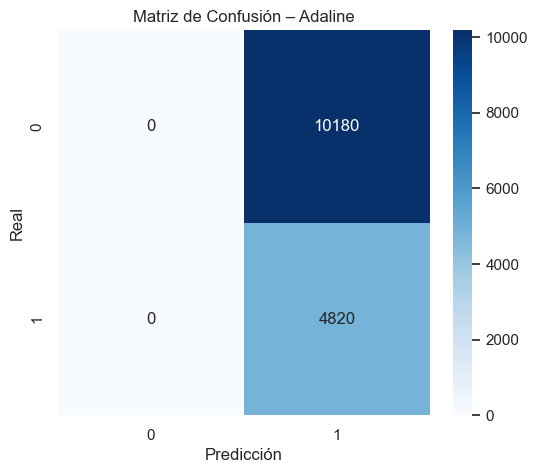

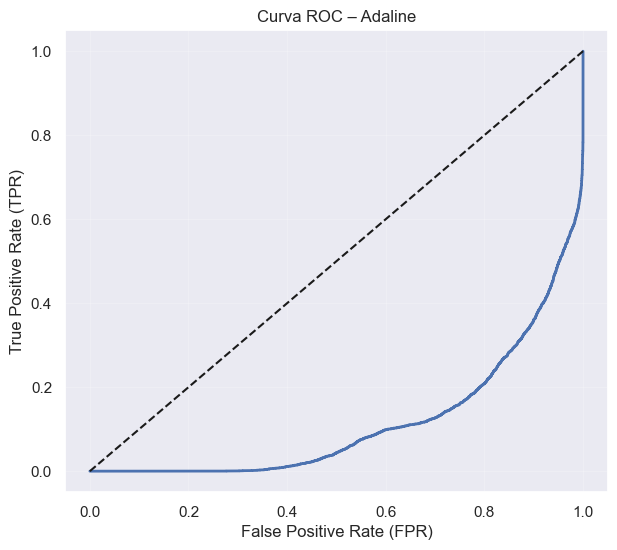

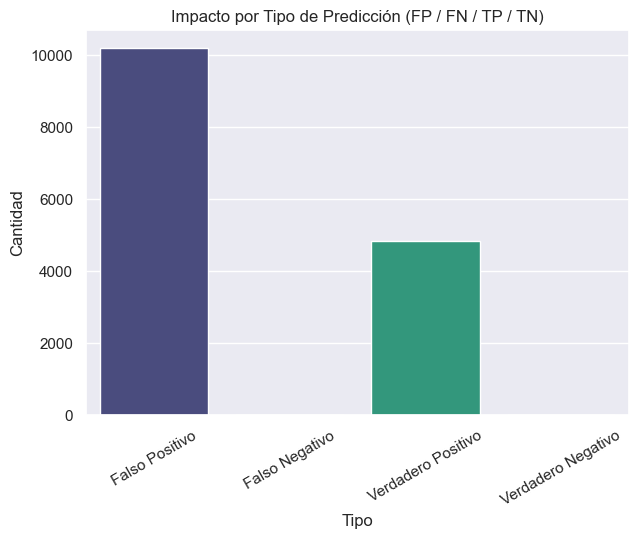

In [28]:
# ===========================================
# 🔹 Evaluación completa del modelo Adaline (corregido)
# ===========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

# -------------------------------------------------------
# 1. Predicciones
# -------------------------------------------------------

y_pred = adaline_pipeline.predict(X_test)

# Adaline usa SIEMPRE decision_function() para scores
y_proba = adaline_pipeline.named_steps["model"].decision_function(
    adaline_pipeline.named_steps["preprocessor"].transform(X_test)
)

# -------------------------------------------------------
# 2. Métricas principales
# -------------------------------------------------------

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("🔹 Métricas del modelo Adaline")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")

# -------------------------------------------------------
# 3. Matriz de confusión
# -------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión – Adaline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# -------------------------------------------------------
# 4. Curva ROC
# -------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.title("Curva ROC – Adaline")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(alpha=0.2)
plt.show()

# -------------------------------------------------------
# 5. Impacto FP / FN
# -------------------------------------------------------

FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
TN = cm[0][0]

impact_df = pd.DataFrame({
    "Tipo": ["Falso Positivo", "Falso Negativo", "Verdadero Positivo", "Verdadero Negativo"],
    "Cantidad": [FP, FN, TP, TN]
})

plt.figure(figsize=(7,5))
sns.barplot(data=impact_df, x="Tipo", y="Cantidad", palette="viridis")
plt.title("Impacto por Tipo de Predicción (FP / FN / TP / TN)")
plt.xticks(rotation=30)
plt.show()




#### 1. Matriz de confusión

En la matriz de confusión se observa:

- **TN (verdaderos negativos) = 0**  
- **FP (falsos positivos) ≈ 10.180**  
- **FN (falsos negativos) = 0**  
- **TP (verdaderos positivos) ≈ 4.820**

Es decir, el modelo **clasifica absolutamente todas las transacciones como fraude (clase 1)**.  
Esto tiene varias implicaciones:

- El **recall para la clase fraude es 1.0** (no deja escapar ningún fraude).
- Pero el **accuracy global es bajo (~32%)**, porque solo acierta cuando realmente había fraude.
- No existen verdaderos negativos: **ninguna transacción legítima fue reconocida como tal**.

En resumen, el modelo se comporta como un clasificador extremo: “marca todo como fraude”.  
Aunque esto maximiza el recall de fraude, **no es un comportamiento útil en un escenario real**, porque genera muchísimas alertas innecesarias.

---

#### 2. Curva ROC

La curva ROC del Adaline se encuentra **cerca de la diagonal**:

- La forma de la curva indica que la capacidad del modelo para separar fraude de no fraude es **limitada**.
- El AUC-ROC es solo ligeramente mejor que el azar (un modelo aleatorio tendría AUC ≈ 0.5).

Esto confirma que, aunque internamente el modelo genera puntuaciones diferentes para las transacciones, **no logra una buena separación entre ambas clases**.  
Al cambiar el umbral de decisión no obtenemos una mejora significativa: el modelo sigue siendo débil para discriminar clientes legítimos de clientes fraudulentos.

---

#### 3. Gráfico de impacto por tipo de predicción (FP / FN / TP / TN)

En el gráfico de barras se ve claramente:

- Una barra muy alta de **Falsos Positivos (FP)**.
- Una cantidad mucho menor de **Verdaderos Positivos (TP)**.
- **Falsos Negativos (FN) y Verdaderos Negativos (TN) prácticamente nulos**.

Desde el punto de vista de negocio:

- **Falsos Positivos** → clientes buenos etiquetados como fraude.  
  - Impacto: bloqueo de cuentas legítimas, fricción en la experiencia, riesgo de perder clientes y dañar la reputación.
- **Falsos Negativos** → en este caso son casi cero, por lo que el banco casi no deja pasar fraudes, pero **al costo** de castigar a muchos usuarios buenos.

---


### 🔹 Modelo – Adaline




🔹 Métricas del modelo MLPClassifier
Accuracy:   0.9959
Precision:  0.9948
Recall:     0.9925
F1-Score:   0.9937
ROC-AUC:    0.9999


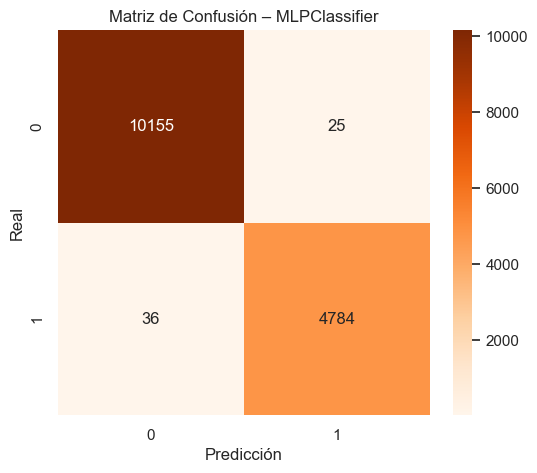

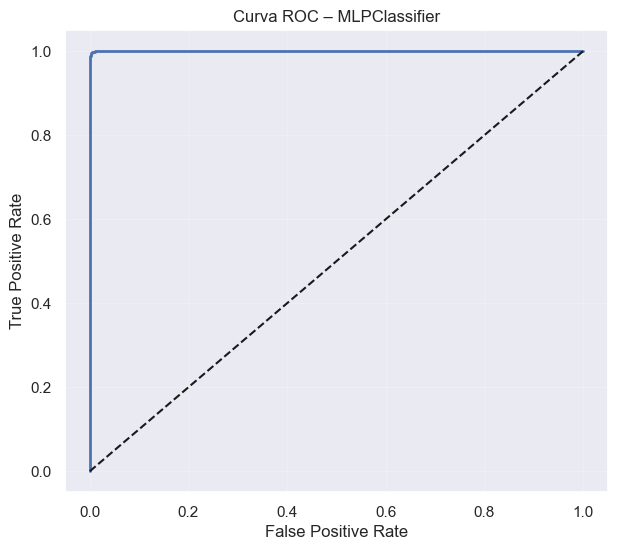

In [35]:
# ===========================================
# 🔹 Modelo Nuevo Individual: MLPClassifier
# ===========================================

from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir el MLP (red neuronal)
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # dos capas ocultas pequeñas
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42
)

# 2. Pipeline completo
mlp_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", mlp_clf)
    ]
)

# 3. Entrenamiento
mlp_pipeline.fit(X_train, y_train)

# 4. Predicciones
y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

# 5. Métricas
print("🔹 Métricas del modelo MLPClassifier")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"F1-Score:   {f1_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_proba_mlp):.4f}")

# 6. Matriz de confusión
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de Confusión – MLPClassifier")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# 7. Curva ROC
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_proba_mlp)
plt.figure(figsize=(7,6))
plt.plot(fpr_mlp, tpr_mlp, linewidth=2)
plt.plot([0,1], [0,1], "k--")
plt.title("Curva ROC – MLPClassifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.2)
plt.show()


#### 1. Resultados numéricos

A partir de la matriz de confusión:

- **TN (verdaderos negativos) = 10.155**
- **FP (falsos positivos) = 25**
- **FN (falsos negativos) = 36**
- **TP (verdaderos positivos) = 4.784**
- Total de ejemplos en test = 15.000

Con estos valores se obtienen:

- **Accuracy ≈ 0,996**
- **Precision ≈ 0,995**
- **Recall ≈ 0,993**
- **F1-Score ≈ 0,994**

Es decir, el modelo acierta en la gran mayoría de los casos y mantiene un equilibrio muy bueno entre precision y recall.

---

#### 2. Matriz de confusión

En la matriz de confusión se observa:

- La mayoría de las transacciones legítimas se clasifican correctamente como **no fraude** (10.155 TN).
- El número de **falsos positivos** es muy bajo (**25**): pocas transacciones buenas se marcan como fraude.
- El número de **falsos negativos** también es muy bajo (**36**): casi todos los fraudes se detectan.
- Los **verdaderos positivos** (**4.784**) muestran que el modelo detecta muy bien las transacciones fraudulentas.

En términos de negocio:

- **FP (25 casos)** → algunos clientes buenos podrían sufrir bloqueos o revisiones manuales, pero es una proporción muy pequeña frente al volumen total.
- **FN (36 casos)** → hay pocos fraudes que se escapan, lo que controla bastante bien el riesgo financiero.

El modelo consigue un **buen compromiso entre proteger al cliente legítimo y evitar pérdidas por fraude**.

---

#### 3. Curva ROC

La curva ROC del MLPClassifier está prácticamente pegada al eje izquierdo y al techo del gráfico:

- La **TPR (True Positive Rate)** es muy alta (≈ 0,99) incluso para valores muy bajos de FPR.
- La **FPR (False Positive Rate)** es muy pequeña (≈ 0,0025), es decir, alrededor del **0,25 %** de las transacciones legítimas se marcan erróneamente como fraude.
- El **AUC-ROC es cercano a 1**, lo que indica una capacidad de discriminación casi perfecta entre fraude y no fraude.

Esto significa que, ajustando el umbral de decisión, el modelo permite explorar distintos puntos de operación manteniendo siempre una separación muy clara entre ambas clases.

---

#### 4. Naturaleza del modelo: red neuronal individual (no meta-clasificador)

El **MLPClassifier** utilizado aquí es una **red neuronal feed-forward** con capas ocultas y función de activación ReLU. Algunas características importantes:

- Es un **modelo individual**, no un ensamble:
  - No combina múltiples clasificadores.
  - No usa votación, bagging, boosting ni stacking.
- El aprendizaje se realiza mediante **backpropagation**:
  - Se calculan los gradientes del error respecto a los pesos de cada capa.
  - Los pesos se actualizan iterativamente con el optimizador *Adam* para minimizar la función de pérdida.
- Gracias a las **capas ocultas y la no linealidad**, el MLP puede capturar relaciones complejas entre las variables de las transacciones, lo que explica el desempeño mucho mejor que el modelo Adaline (lineal).


# Meta clasificador (BORRAR EN UN FUTURO SI NO SE LLEGA A USAR)

X_train: (35000, 17)
X_test : (15000, 17)
Numéricas: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categóricas: ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']

🔹 MÉTRICAS – ExtraTreesClassifier
Accuracy:   0.9837
Precision:  0.9983
Recall:     0.9510
F1-Score:   0.9741
ROC-AUC:    0.9998


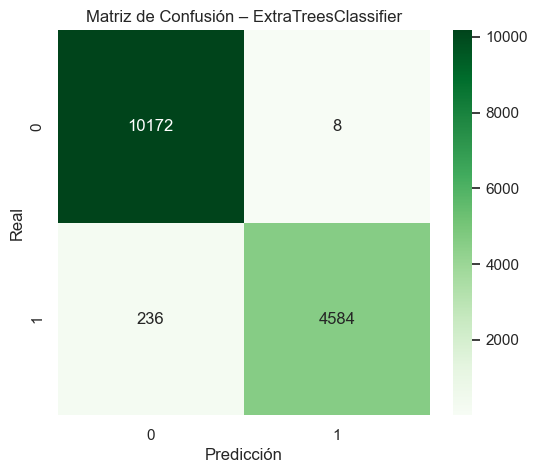


Falsos Positivos: 8
Falsos Negativos: 236


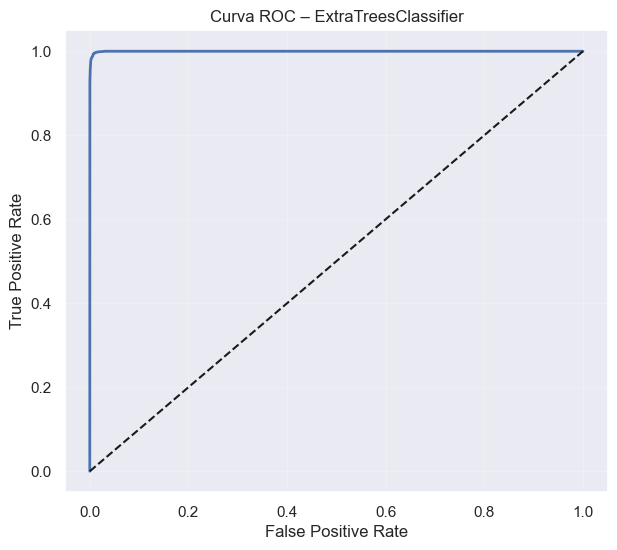

In [34]:
# ===========================================
# 🔹 Modelo Nuevo: ExtraTreesClassifier con Pipeline
# ===========================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------------------------------------
# 1. Separar datos y variable objetivo
# -------------------------------------------------------

target_col = "Fraud_Label"   # Ajusta si tu columna objetivo tiene otro nombre

cols_to_drop = ["Transaction_ID", "User_ID", "Timestamp"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns=[target_col])
y = df_model[target_col]


# -------------------------------------------------------
# 2. Train/Test split
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# -------------------------------------------------------
# 3. Identificación automática de columnas
# -------------------------------------------------------

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)


# -------------------------------------------------------
# 4. Preprocesamiento (ColumnTransformer)
# -------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


# -------------------------------------------------------
# 5. Definir el modelo ExtraTrees
# -------------------------------------------------------

extratrees_clf = ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # ayuda con el desbalance
)


# -------------------------------------------------------
# 6. Pipeline completo: preprocesamiento + modelo
# -------------------------------------------------------

extratrees_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", extratrees_clf)
    ]
)


# -------------------------------------------------------
# 7. Entrenamiento
# -------------------------------------------------------

extratrees_pipeline.fit(X_train, y_train)


# -------------------------------------------------------
# 8. Predicciones
# -------------------------------------------------------

y_pred_et = extratrees_pipeline.predict(X_test)
y_proba_et = extratrees_pipeline.predict_proba(X_test)[:, 1]


# -------------------------------------------------------
# 9. Métricas
# -------------------------------------------------------

acc = accuracy_score(y_test, y_pred_et)
prec = precision_score(y_test, y_pred_et, zero_division=0)
rec = recall_score(y_test, y_pred_et, zero_division=0)
f1 = f1_score(y_test, y_pred_et, zero_division=0)
roc = roc_auc_score(y_test, y_proba_et)

print("\n🔹 MÉTRICAS – ExtraTreesClassifier")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc:.4f}")


# -------------------------------------------------------
# 10. Matriz de confusión
# -------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_et)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión – ExtraTreesClassifier")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
TN = cm[0][0]

print("\nFalsos Positivos:", FP)
print("Falsos Negativos:", FN)


# -------------------------------------------------------
# 11. Curva ROC
# -------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_proba_et)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], "k--")
plt.title("Curva ROC – ExtraTreesClassifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.2)
plt.show()
